In [70]:
# Environment Setup

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [72]:
# Custom Prunable Layer

In [73]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.bias = nn.Parameter(torch.Tensor(out_features))
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.zeros_(self.bias)
        nn.init.constant_(self.gate_scores, 0.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        return F.linear(x, self.weight * gates, self.bias)

In [74]:
# Build Neural Network

In [75]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super(SelfPruningNet, self).__init__()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(-1, 3072)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

    def get_sparsity_loss(self):
        loss = 0
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                loss += torch.sigmoid(m.gate_scores).abs().sum()
        return loss

In [76]:
# Training and Evaluation Logic

In [77]:
def run_training(lam, epochs=10):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

    train_loader = DataLoader(datasets.CIFAR10(root='./data', train=True, download=True, transform=transform),
                              batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
    test_loader = DataLoader(datasets.CIFAR10(root='./data', train=False, download=True, transform=transform),
                             batch_size=1000, shuffle=False, num_workers=0, pin_memory=True)

    model = SelfPruningNet().to(device)
    optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'gate_scores' not in n], 'lr': 1e-3},
    {'params': [p for n, p in model.named_parameters() if 'gate_scores' in n], 'lr': 1e-2} # Higher LR for gates
    ])
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)

            ce_loss = criterion(output, target)
            total_loss = ce_loss + lam * (model.get_sparsity_loss()/1000)

            total_loss.backward()
            optimizer.step()

    model.eval()
    correct, total_w, pruned_w = 0, 0, 0
    all_gates = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            correct += output.argmax(dim=1).eq(target).sum().item()

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            g = torch.sigmoid(m.gate_scores).detach().cpu().numpy()
            all_gates.extend(g.flatten())
            total_w += g.size
            pruned_w += np.sum(g < 0.1)
    return 100. * correct / 10000, (pruned_w / total_w) * 100, all_gates

In [78]:
# Execution and results visualization

Lambda     | Accuracy (%)    | Sparsity (%)   
---------------------------------------------
0.001      | 56.33           | 64.47          
0.01       | 54.18           | 97.33          
0.1        | 50.82           | 99.84          


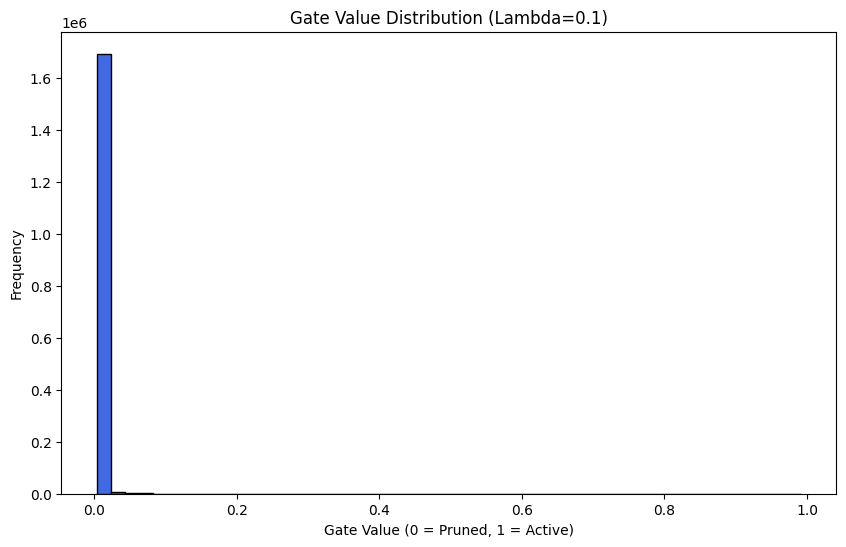

In [79]:
lambdas = [0.001,0.01,0.1]
print(f"{'Lambda':<10} | {'Accuracy (%)':<15} | {'Sparsity (%)':<15}")
print("-" * 45)

for l in lambdas:
    acc, sp, gates = run_training(l, epochs=10)
    print(f"{l:<10} | {acc:<15.2f} | {sp:<15.2f}")

plt.figure(figsize=(10,6))
plt.hist(gates, bins=50, color='royalblue', edgecolor='black')
plt.title(f"Gate Value Distribution (Lambda={l})")
plt.xlabel("Gate Value (0 = Pruned, 1 = Active)")
plt.ylabel("Frequency")
plt.show()